# Project 4 — Data Visualization & Storytelling

**DecodeLabs Industrial Training Kit | Batch 2026**

## Project objective
Turn the supplied order dataset into clear, decision-oriented visual insights. The project follows the PDF's three pillars:

1. **Choose with Purpose (The Architect)** — match the chart to the business question.
2. **Edit with Precision (The Editor)** — protect axis integrity, remove chartjunk, use direct labels, and avoid unnecessary 3D.
3. **Tell a Story (The Storyteller)** — use action titles, the SCR framework, and always answer **“So What?”**

> **Important:** `TotalPrice` is treated as **order value** in this analysis. Because the data contains Cancelled and Returned orders, it is not automatically described as realized revenue or profit.


## What is expected of me.

### Task 1 — Define the analytical questions
Create business questions before choosing charts.

### Task 2 — Load and inspect the Excel data
Check shape, columns, data types, missing values, duplicates, and date coverage.

### Task 3 — Prepare the data
Standardize column names and create analysis fields such as year, month, month name, and order value.

### Task 4 — Establish the baseline
Calculate core KPIs that give the audience the five-second context.

### Task 5 — Compare categories
Use bar charts for product, payment method, and referral-source comparisons.

### Task 6 — Show trends
Use a line chart for monthly order-value movement and compare years carefully because 2025 contains only part of the year.

### Task 7 — Show composition/status
Use a bar chart for order-status distribution rather than relying on a crowded pie chart.

### Task 8 — Investigate relationships
Use a scatter plot to examine Quantity versus TotalPrice.

### Task 9 — Write the story
Use action titles, chart annotations/labels, and the Situation → Complication → Resolution (SCR) structure.

### Task 10 — Answer “So What?”
Translate the observed patterns into practical analytical recommendations without claiming causation where the dataset does not prove it.


## Task 1 — Define the analytical questions

**Business questions used in this notebook:**
- Which products generate the most order value?
- How does order value move over time?
- How does performance differ by year, while accounting for partial 2025 coverage?
- What is the distribution of order statuses?
- Which payment methods and referral sources account for the most order value?
- Is larger quantity generally associated with higher order value?

**Chart-selection rule from the PDF:** comparisons → bar/column; trends → line; relationships → scatter; composition → stacked bar where appropriate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_excel("Dataset_for_Data_Analytics.xlsx")

df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10"
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40"
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04"


### Task 2 — Inspect the dataset

**Why:** before visualizing, confirm that the fields, types, missing values, and duplicates are understood.

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDate coverage:")
print(df["Date"].min(), "to", df["Date"].max())


Shape: (1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types:


,dtype
OrderID,str
Date,datetime64[us]
CustomerID,str
Product,str
Quantity,int64
UnitPrice,float64
ShippingAddress,str
PaymentMethod,str
OrderStatus,str
TrackingNumber,str



Missing values:


,missing
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0



Duplicate rows: 0

Date coverage:
2023-01-01 00:00:00 to 2025-06-30 00:00:00


### Task 3 — Prepare the data

The source contains 1,200 rows and one optional field, `CouponCode`, with missing values. Missing coupon codes are not automatically errors: they can represent orders where no coupon was recorded. We therefore preserve the raw field and create analysis-ready date fields.

In [3]:
# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# Parse date safely
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check invalid dates
print("Invalid dates:", df["date"].isna().sum())

# Create analysis fields
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["month_period"] = df["date"].dt.to_period("M")

# Preserve a clean working copy
df_clean = df.copy()

print("Clean shape:", df_clean.shape)
display(df_clean.head())


Invalid dates: 0
Clean shape: (1200, 18)


,orderid,date,customerid,product,quantity,unitprice,shippingaddress,paymentmethod,orderstatus,trackingnumber,itemsincart,couponcode,referralsource,totalprice,year,month,month_name,month_period
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,"2,853.10",2023,1,January,2023-01
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,8,August,2024-08
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,"2,753.40",2024,2,February,2024-02
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,10,October,2023-10
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,"2,504.04",2025,5,May,2025-05


## Task 4 — Baseline KPIs

These metrics establish the current scale before the audience sees detailed charts.

In [4]:
total_orders = df_clean["orderid"].nunique()
total_order_value = df_clean["totalprice"].sum()
avg_order_value = df_clean["totalprice"].mean()
total_quantity = df_clean["quantity"].sum()
unique_customers = df_clean["customerid"].nunique()

kpis = pd.Series({
    "Total orders": total_orders,
    "Total order value": total_order_value,
    "Average order value": avg_order_value,
    "Total quantity": total_quantity,
    "Unique customers": unique_customers
})

display(kpis.to_frame("value"))


,value
Total orders,"1,200.00"
Total order value,"1,264,761.96"
Average order value,"1,053.97"
Total quantity,"3,535.00"
Unique customers,"1,189.00"


## Task 5 — Product performance

**Question:** Which products generate the most order value?

**Visual choice:** horizontal bar chart because the task compares categories. The bars use a zero baseline and direct numeric labels.

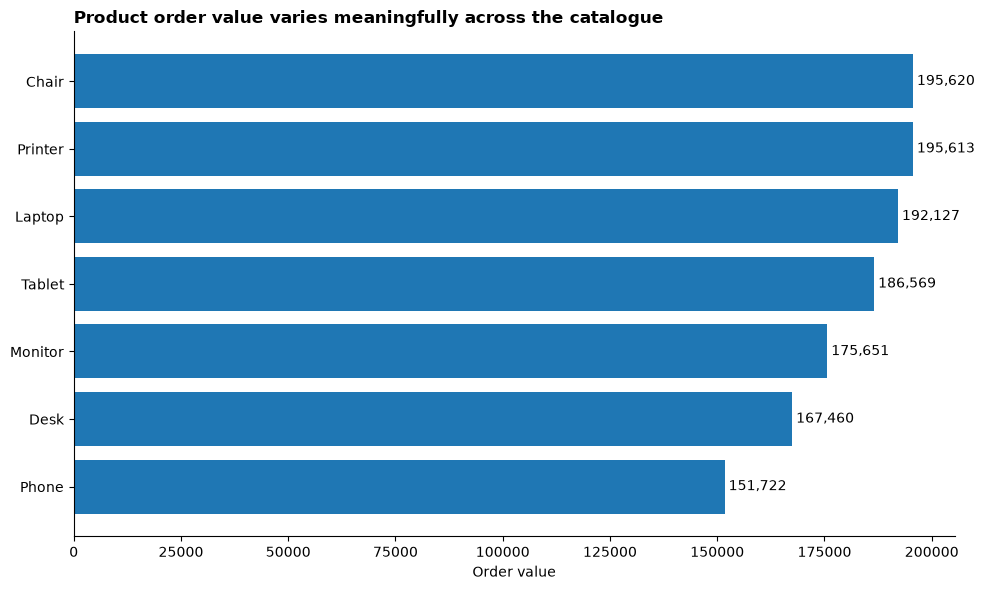

,product,orders,quantity,order_value
0,Chair,178,562,"195,620.11"
5,Printer,181,542,"195,612.61"
2,Laptop,173,535,"192,126.56"
6,Tablet,179,497,"186,568.95"
3,Monitor,163,480,"175,651.41"
1,Desk,170,508,"167,459.93"
4,Phone,156,411,"151,722.39"


In [5]:
product_summary = (
    df_clean.groupby("product", as_index=False)
            .agg(orders=("orderid", "nunique"),
                 quantity=("quantity", "sum"),
                 order_value=("totalprice", "sum"))
            .sort_values("order_value")
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(product_summary["product"], product_summary["order_value"])
ax.set_title("Product order value varies meaningfully across the catalogue", loc="left", weight="bold")
ax.set_xlabel("Order value")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)

for bar, value in zip(bars, product_summary["order_value"]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f" {value:,.0f}", va="center")

plt.tight_layout()
plt.show()

display(product_summary.sort_values("order_value", ascending=False))


**Insight:** The chart identifies the products with the largest recorded order value. This is a descriptive result; the dataset alone does not establish why one product performs differently from another.

**So What?** Use the product ranking to decide where to investigate pricing, demand, stock availability, promotions, and customer mix.

## Task 6 — Monthly trend

**Question:** How does order value change over time?

**Visual choice:** line chart because time is continuous. The title states the takeaway rather than merely naming the chart.

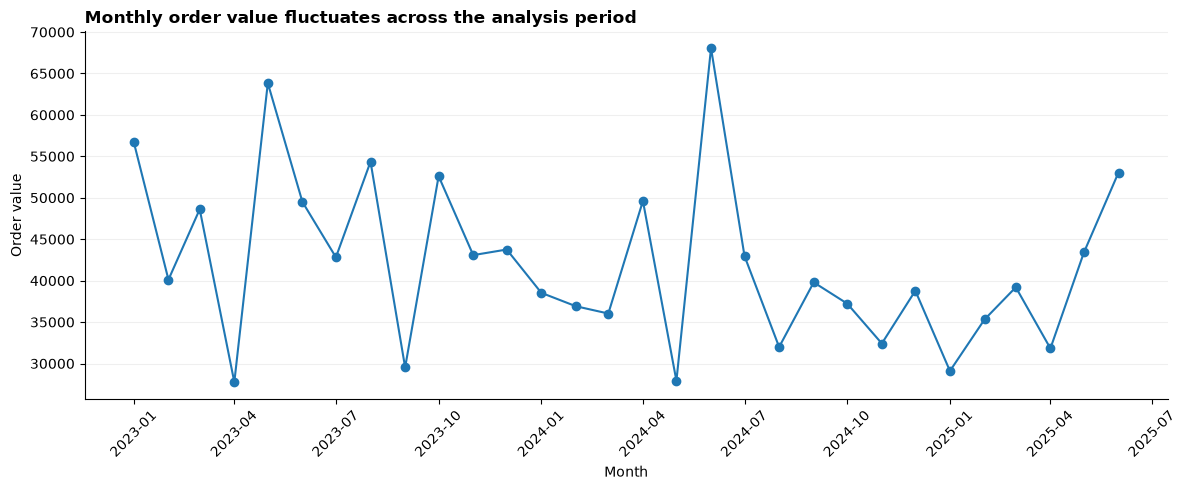

,month_period,order_value,orders,month
17,2024-06,"68,068.54",53,2024-06-01
4,2023-05,"63,836.84",49,2023-05-01
0,2023-01,"56,685.75",47,2023-01-01
7,2023-08,"54,352.14",51,2023-08-01
29,2025-06,"53,047.40",49,2025-06-01
9,2023-10,"52,607.85",47,2023-10-01
15,2024-04,"49,613.14",50,2024-04-01
5,2023-06,"49,500.19",45,2023-06-01
2,2023-03,"48,609.37",43,2023-03-01
11,2023-12,"43,754.73",46,2023-12-01


In [6]:
monthly = (
    df_clean.groupby("month_period", as_index=False)
            .agg(order_value=("totalprice", "sum"),
                 orders=("orderid", "nunique"))
)
monthly["month"] = monthly["month_period"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly["month"], monthly["order_value"], marker="o")
ax.set_title("Monthly order value fluctuates across the analysis period", loc="left", weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Order value")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly.sort_values("order_value", ascending=False).head(10))


**Insight:** The monthly series shows where order-value peaks and dips occur.

**So What?** Investigate unusually high or low months against product mix, order status, promotions, referral source, and payment method before taking action.

## Task 7 — Yearly comparison with coverage warning

The dataset runs from January 2023 through June 2025. Therefore, 2025 is a **partial year** and should not be presented as a directly comparable full-year total.

,year,orders,order_value
0,2023,510,"552,643.24"
1,2024,459,"480,235.87"
2,2025,231,"231,882.85"


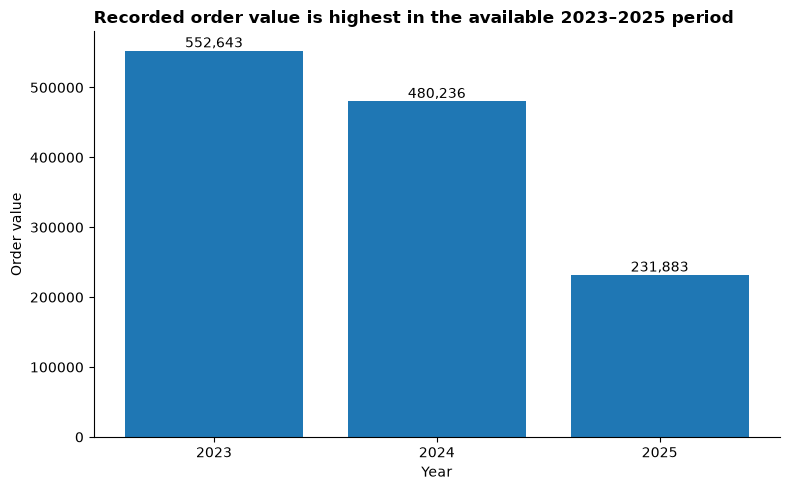

In [7]:
year_summary = (
    df_clean.groupby("year", as_index=False)
            .agg(orders=("orderid", "nunique"),
                 order_value=("totalprice", "sum"))
)
display(year_summary)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(year_summary["year"].astype(str), year_summary["order_value"])
ax.set_title("Recorded order value is highest in the available 2023–2025 period", loc="left", weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Order value")
ax.spines[["top", "right"]].set_visible(False)

for bar, value in zip(bars, year_summary["order_value"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{value:,.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


**Important interpretation:** 2025 contains only January–June in this dataset, so its lower total is partly a coverage effect. A like-for-like year-to-date comparison would be preferable for a performance conclusion.

## Task 8 — Order-status distribution

**Question:** How are orders distributed across statuses?

**Visual choice:** bar chart. This follows the PDF guidance to avoid unnecessary pie charts and makes category comparison easier.

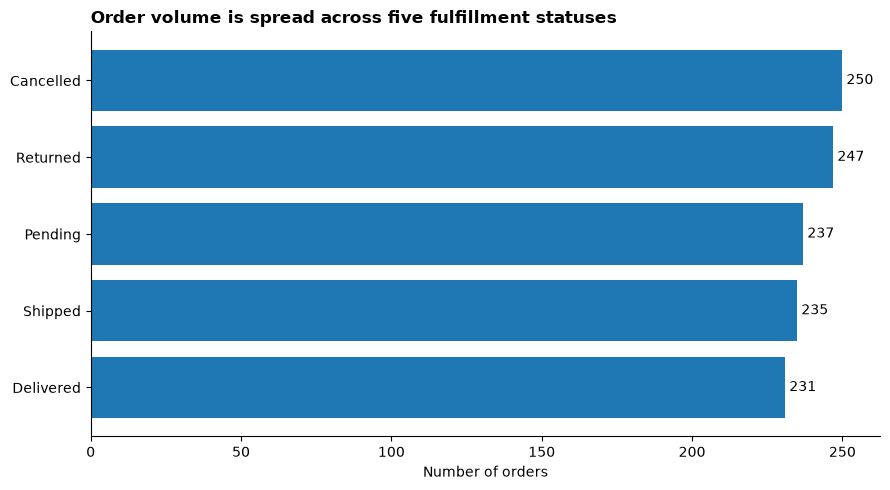

,order_status,orders
0,Cancelled,250
1,Returned,247
2,Pending,237
3,Shipped,235
4,Delivered,231


In [8]:
status_summary = (
    df_clean["orderstatus"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
    .sort_values("orders")
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(status_summary["order_status"], status_summary["orders"])
ax.set_title("Order volume is spread across five fulfillment statuses", loc="left", weight="bold")
ax.set_xlabel("Number of orders")
ax.set_ylabel("")
ax.spines[["top", "right"]].set_visible(False)

for bar, value in zip(bars, status_summary["orders"]):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f" {value:,}", va="center")

plt.tight_layout()
plt.show()

display(status_summary.sort_values("orders", ascending=False))


**So What?** Treat Cancelled and Returned orders as operational signals worth monitoring. This dataset supports measuring their volume and order value, but it does not explain the causes.

## Task 9 — Payment method and referral source comparisons

These are category comparisons, so bar charts are used. Direct labels keep the charts readable without forcing the audience to decode a legend.

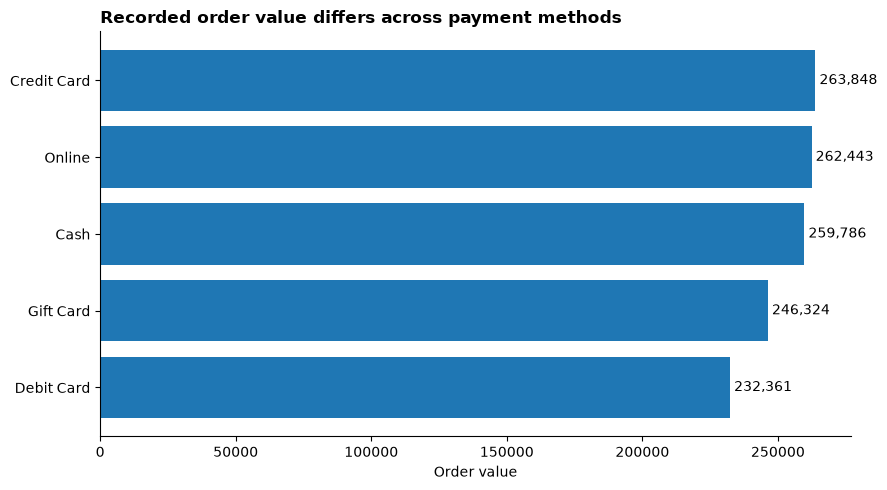

,order_value
paymentmethod,
Credit Card,"263,847.63"
Online,"262,442.94"
Cash,"259,786.29"
Gift Card,"246,323.92"
Debit Card,"232,361.18"


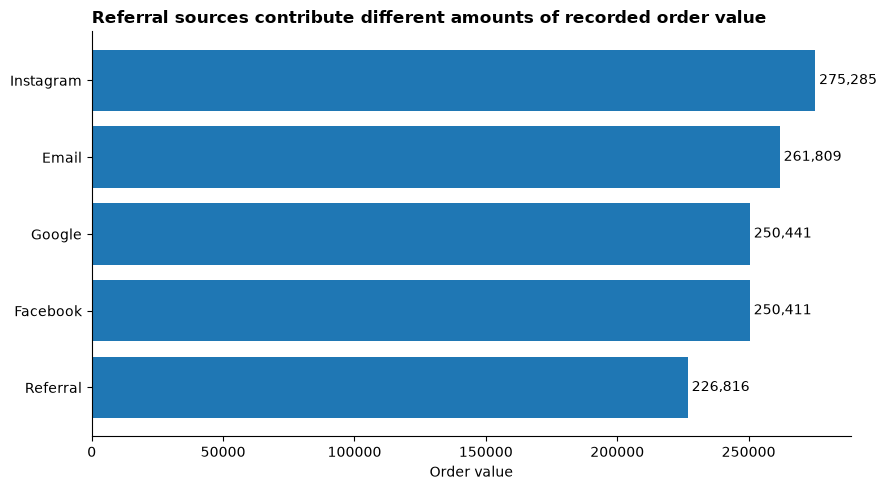

,order_value
referralsource,
Instagram,"275,285.45"
Email,"261,808.55"
Google,"250,441.48"
Facebook,"250,410.90"
Referral,"226,815.58"


In [9]:
def category_value_chart(data, category, value, title, xlabel):
    s = (data.groupby(category)[value].sum()
           .sort_values())
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(s.index, s.values)
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.spines[["top", "right"]].set_visible(False)
    for bar, v in zip(bars, s.values):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f" {v:,.0f}", va="center")
    plt.tight_layout()
    plt.show()
    return s.sort_values(ascending=False).rename("order_value").to_frame()

payment_summary = category_value_chart(
    df_clean, "paymentmethod", "totalprice",
    "Recorded order value differs across payment methods",
    "Order value"
)
display(payment_summary)

referral_summary = category_value_chart(
    df_clean, "referralsource", "totalprice",
    "Referral sources contribute different amounts of recorded order value",
    "Order value"
)
display(referral_summary)


**Insight:** These rankings describe where recorded order value came from; they do not measure profitability, customer acquisition cost, or conversion rate.

**So What?** Pair referral-source value with acquisition cost and conversion metrics if the business wants to decide where to increase marketing investment.

## Task 10 — Quantity versus TotalPrice relationship

**Question:** Is larger quantity generally associated with larger order value?

**Visual choice:** scatter plot because the question investigates a relationship between two numeric variables.

Pearson correlation between Quantity and TotalPrice: 0.615


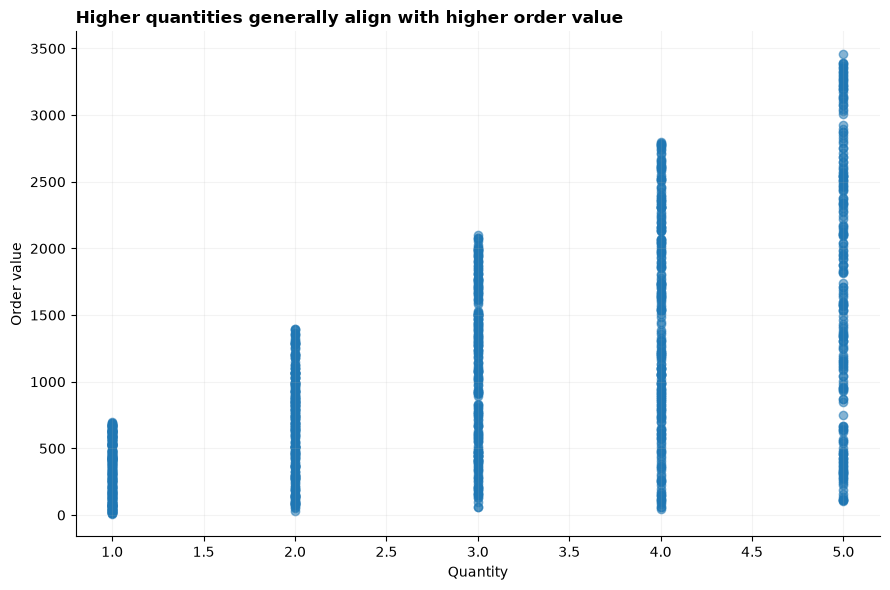

In [10]:
corr = df_clean["quantity"].corr(df_clean["totalprice"])
print(f"Pearson correlation between Quantity and TotalPrice: {corr:.3f}")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_clean["quantity"], df_clean["totalprice"], alpha=0.55)
ax.set_title("Higher quantities generally align with higher order value", loc="left", weight="bold")
ax.set_xlabel("Quantity")
ax.set_ylabel("Order value")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


**Insight:** The correlation is positive in this dataset, meaning larger quantities tend to be associated with higher order values. Correlation is not proof of causation.

**So What?** Consider quantity-based basket analysis and product-level pricing analysis before designing volume promotions.

# Task 11 — Data-storytelling checklist

Before submitting, check:

- **Form follows function:** every chart answers a stated question.
- **Axis integrity:** bar charts start at zero.
- **No distortion:** avoid 3D effects.
- **Data-ink ratio:** remove decorative elements that do not improve understanding.
- **Direct labeling:** important values are written on the visual where practical.
- **Color discipline:** use color to highlight, not decorate.
- **One message at a time:** do not overload a chart with unrelated questions.
- **Action title:** the title communicates the main conclusion.
- **Five-second rule:** a reader should quickly see the problem/message.
- **So What?:** every finding is connected to a next analytical/business action.


# Task 12 — SCR Story

## Situation
The dataset contains 1,200 orders dated from January 2023 through June 2025. The baseline analysis shows a broad mix of products, payment methods, referral sources, and order statuses.

## Complication
Order value is not distributed evenly across all categories, monthly order value fluctuates, and a substantial number of orders are recorded as Cancelled or Returned. At the same time, 2025 is only a partial year, which limits direct full-year comparison.

## Resolution
Use the visual findings as a diagnostic starting point: investigate product-level drivers, monthly peaks/dips, cancelled/returned orders, and acquisition-source performance. For management decisions, add missing business measures such as margin, fulfilment cost, conversion rate, and reason codes before making causal or profitability claims.

## Final“So What?”
The project demonstrates that visualization is not simply chart creation: the analyst must connect the right visual to the question, explain the evidence, state its limitations, and identify the next decision or analysis.
